In [2]:
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.colors as col
from sklearn.metrics import r2_score
import statsmodels.api as sm
import numpy as np
import helpers
import netCDF4 as nc
import cartopy.crs as ccrs
import pyproj
import csv
import rasterio
from rasterio.plot import show
import pyproj
from scipy.signal import convolve2d
import datetime as dt
import matplotlib.patches as patches
import os
import helpers

In [25]:
#merge tif files together
#run in jupyter
from pathlib import Path
from osgeo import gdal
import os
BASE_PATH = 'C:/Users/yehuang/OneDrive - UCL/python/data/DSM/Brussels_split'
newpath = r'C:/Users/yehuang/OneDrive - UCL/python/data/DSM/Brussels_split/'
f_list = ['1kmE3919N3092','1kmE3930N3097', '1kmE3929N3101', '1kmE3929N3102', '1kmE3926N3103', '1kmE3921N3102', '1kmE3931N3096', '1kmE3931N3095', '1kmE3931N3094', '1kmE3931N3093', '1kmE3931N3090', '1kmE3930N3096', '1kmE3930N3095', '1kmE3930N3094', '1kmE3930N3093', '1kmE3930N3091', '1kmE3930N3090', '1kmE3929N3100', '1kmE3929N3099', '1kmE3929N3098', '1kmE3929N3097', '1kmE3929N3096', '1kmE3929N3095', '1kmE3929N3094', '1kmE3929N3093', '1kmE3929N3092', '1kmE3929N3091', '1kmE3929N3090', '1kmE3929N3089', '1kmE3928N3103', '1kmE3928N3102', '1kmE3928N3101', '1kmE3928N3100', '1kmE3928N3099', '1kmE3928N3098', '1kmE3928N3097', '1kmE3928N3096', '1kmE3928N3095', '1kmE3928N3094', '1kmE3928N3093', '1kmE3928N3092', '1kmE3928N3091', '1kmE3928N3090', '1kmE3928N3089', '1kmE3927N3103', '1kmE3927N3102', '1kmE3927N3101', '1kmE3927N3100', '1kmE3927N3099', '1kmE3927N3098', '1kmE3927N3097', '1kmE3927N3096', '1kmE3927N3095', '1kmE3927N3094', '1kmE3927N3093', '1kmE3927N3092', '1kmE3927N3091', '1kmE3927N3090', '1kmE3927N3089', '1kmE3926N3102', '1kmE3926N3101', '1kmE3926N3100', '1kmE3926N3099', '1kmE3926N3098', '1kmE3926N3097', '1kmE3926N3096', '1kmE3926N3095', '1kmE3926N3094', '1kmE3926N3093', '1kmE3926N3092', '1kmE3926N3091', '1kmE3926N3090', '1kmE3926N3089', '1kmE3926N3088', '1kmE3925N3102', '1kmE3925N3101', '1kmE3925N3100', '1kmE3925N3099', '1kmE3925N3098', '1kmE3925N3097', '1kmE3925N3096', '1kmE3925N3095', '1kmE3925N3094', '1kmE3925N3093', '1kmE3925N3092', '1kmE3925N3091', '1kmE3925N3090', '1kmE3925N3089', '1kmE3925N3088', '1kmE3924N3102', '1kmE3924N3101', '1kmE3924N3100', '1kmE3924N3099', '1kmE3924N3098', '1kmE3924N3097', '1kmE3924N3096', '1kmE3924N3095', '1kmE3924N3094', '1kmE3924N3093', '1kmE3924N3092', '1kmE3924N3091', '1kmE3924N3090', '1kmE3924N3089', '1kmE3923N3102', '1kmE3923N3101', '1kmE3923N3100', '1kmE3923N3099', '1kmE3923N3098', '1kmE3923N3097', '1kmE3923N3096', '1kmE3923N3095', '1kmE3923N3094', '1kmE3923N3093', '1kmE3923N3092', '1kmE3923N3091', '1kmE3923N3090', '1kmE3923N3089', '1kmE3922N3102', '1kmE3922N3101', '1kmE3922N3100', '1kmE3922N3099', '1kmE3922N3098', '1kmE3922N3097', '1kmE3922N3096', '1kmE3922N3095', '1kmE3922N3094', '1kmE3922N3093', '1kmE3922N3092', '1kmE3922N3091', '1kmE3922N3090', '1kmE3922N3089', '1kmE3921N3101', '1kmE3921N3100', '1kmE3921N3099', '1kmE3921N3098', '1kmE3921N3097', '1kmE3921N3096', '1kmE3921N3095', '1kmE3921N3094', '1kmE3921N3093', '1kmE3921N3092', '1kmE3921N3091', '1kmE3921N3090', '1kmE3921N3089', '1kmE3920N3101', '1kmE3920N3100', '1kmE3920N3099', '1kmE3920N3098', '1kmE3920N3097', '1kmE3920N3096', '1kmE3920N3095', '1kmE3920N3094', '1kmE3920N3093', '1kmE3920N3092', '1kmE3919N3099', '1kmE3919N3098', '1kmE3919N3097', '1kmE3919N3096', '1kmE3919N3095', '1kmE3919N3094', '1kmE3919N3093', '1kmE3918N3096', '1kmE3918N3095', '1kmE3918N3094', '1kmE3918N3093', '1kmE3917N3095', '1kmE3917N3094', '1kmE3916N3094', '1kmE3924N3088', '1kmE3923N3088', '1kmE3920N3090', '1kmE3920N3091', '1kmE3917N3093', '1kmE3916N3095', '1kmE3917N3096', '1kmE3918N3097', '1kmE3918N3099', '1kmE3919N3100']
print(len(f_list))
org = ['SVF_clipped_', 'svf_noVeg_clipped_','svf_Veg_clipped_']#list all the tif files under a path
f_l = []
# Iterate over each prefix from org list
for prefix in org:
    # Create list to hold file paths
    f_l = []

    # Iterate over each block in the file list
    for block in f_list:
        # Construct the full file path
        f_path = os.path.join(BASE_PATH, block, f'{prefix}{block}.tif')
        print(f_path)

        # Check if the file exists before adding it to the list
        if os.path.exists(f_path):
            f_l.append(f_path)
        else:
            print(f"File not found: {f_path}")

    # Ensure there are files to process
    if f_l:
        # Create a VRT from the list of files
        vrt_path = os.path.join(BASE_PATH, f'{prefix}prov_vrt.vrt')
        vrt = gdal.BuildVRT(vrt_path, f_l)

        # Define the output file path
        result_path = os.path.join(BASE_PATH, f'{prefix}merged.tif')

        # Translate the VRT to a GeoTIFF
        gdal.Translate(result_path, vrt, format='GTiff')

        # Destroy the VRT dataset to release resources
        vrt = None
    else:
        print(f"No files found for prefix {prefix}")

print("Merging completed.")

178
C:/Users/yehuang/OneDrive - UCL/python/data/DSM/Brussels_split\1kmE3919N3092\SVF_clipped_1kmE3919N3092.tif
C:/Users/yehuang/OneDrive - UCL/python/data/DSM/Brussels_split\1kmE3930N3097\SVF_clipped_1kmE3930N3097.tif
C:/Users/yehuang/OneDrive - UCL/python/data/DSM/Brussels_split\1kmE3929N3101\SVF_clipped_1kmE3929N3101.tif
C:/Users/yehuang/OneDrive - UCL/python/data/DSM/Brussels_split\1kmE3929N3102\SVF_clipped_1kmE3929N3102.tif
C:/Users/yehuang/OneDrive - UCL/python/data/DSM/Brussels_split\1kmE3926N3103\SVF_clipped_1kmE3926N3103.tif
C:/Users/yehuang/OneDrive - UCL/python/data/DSM/Brussels_split\1kmE3921N3102\SVF_clipped_1kmE3921N3102.tif
C:/Users/yehuang/OneDrive - UCL/python/data/DSM/Brussels_split\1kmE3931N3096\SVF_clipped_1kmE3931N3096.tif
C:/Users/yehuang/OneDrive - UCL/python/data/DSM/Brussels_split\1kmE3931N3095\SVF_clipped_1kmE3931N3095.tif
C:/Users/yehuang/OneDrive - UCL/python/data/DSM/Brussels_split\1kmE3931N3094\SVF_clipped_1kmE3931N3094.tif
C:/Users/yehuang/OneDrive - UCL/p

# generate grid metero

In [2]:
#load cdsapi meteoro data
year = '2011'
df_TMYx_compare = pd.read_csv('./data/meteorology/Brussels/meteo_cdsapi_'+year+'.epw', sep = ',', skiprows=8, names=['Year', 'Month', 'Day', 'Hour', 'Minute', 'IDN', 'DBT', 'DPT', 'RH', 'ASP', 'EHR', 'EDNR', 'HIRI', 'GHR', 'DNR', 'DHR', \
                                                                      'HI', 'NI', 'HII', 'ZI', 'WD', 'WS', 'TSC', 'OSC', 'VIS', 'CH', 'PWO', 'PWc', 'PW', 'AOD', 'SD', 'DSLS', 'Albedo', 'LPD', 'LPQ','idn'])
#print(df_station.head())

In [11]:
import pip
#pip install metpy
#pip install statsmodels
pip.main(['install', 'pythermalcomfort'])
#pip install pythermalcomfort #wierd error

Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


Collecting pythermalcomfort

Downloading pythermalcomfort-3.0.0-py2.py3-none-any.whl.metadata (17 kB)

Requirement already satisfied: scipy in c:\users\uu703\anaconda3\envs\env\lib\site-packages (from pythermalcomfort) (1.13.1)

Collecting numba (from pythermalcomfort)

...

C:\Users\uu703\anaconda3\envs\env\lib\site-packages\pip\_vendor\rich\live.py:231: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Downloading llvmlite-0.44.0-cp310-cp310-win_amd64.whl (30.3 MB)

Installing collected packages: llvmlite, numba, pythermalcomfort

Successfully installed llvmlite-0.44.0 numba-0.61.0 pythermalcomfort-3.0.0

0

In [4]:
from metpy.units import units
import metpy.calc as mpcalc

#PRODUCE NC FILE
item = 0 #0=Air_temp, 1=RH, 2=Wind
#year = '2010'
folder = ['Air_temp_brussels', 'Relative_humidity_brussels', 'Wind_speed_brussels']
file = ['tas', 'russ', 'sfcWind']
output = ['Air_temp', 'RH', 'Wind']
#output = ['Air_temp', 'RH', 'Wind']
ncFile0 = nc.Dataset('./data/Meteorology/Brussels/'+folder[0]+'/'+output[0]+'_brussels_' + year + '.nc', "r", format="NETCDF4")
temp = ncFile0.variables[file[0]][::].data -273.15
temp = np.round(temp,2)

ncFile1 = nc.Dataset('./data/Meteorology/Brussels/'+folder[1]+'/'+output[1]+'_brussels_' + year + '.nc', "r", format="NETCDF4")
RH = ncFile1.variables[file[1]][::].data
RH = np.round(RH,0)

temperature = temp * units.degC
rel_humidity  = RH * units.percent
dew = mpcalc.dewpoint_from_relative_humidity(temperature, rel_humidity)
dew = np.round(dew,2)

ncFile2 = nc.Dataset('./data/Meteorology/Brussels/'+folder[2]+'/'+output[2]+'_brussels_' + year + '.nc', "r", format="NETCDF4")
wind = ncFile2.variables[file[2]][::].data
wind = np.round(wind,2)

#ncFile3 = nc.Dataset('./data/meteorology/Brussels/Solar_grid/Solar_2012.nc',mode='r',format='NETCDF4_CLASSIC') 
df_solar = pd.read_csv('./data/meteorology/Brussels/Solar/solar_'+year+'.csv')
col_list = ['BNI', 'BHI', 'DHI', 'GHI']
BNI = df_solar[col_list[0]][::]
#BHI = ncFile3.variables[col_list[1]][::].data
DHI = df_solar[col_list[2]][::]
GHI = df_solar[col_list[3]][::]


x = ((ncFile0.variables['x'][::].data - 500)/1000).astype(int)
y = ((ncFile0.variables['y'][::].data - 500)/1000).astype(int)
print(y)
print(x)

ncFile0.close()
ncFile1.close()
ncFile2.close()



[3110 3109 3108 3107 3106 3105 3104 3103 3102 3101 3100 3099 3098 3097
 3096 3095 3094 3093 3092 3091 3090 3089 3088 3087 3086 3085 3084 3083
 3082]
[3911 3912 3913 3914 3915 3916 3917 3918 3919 3920 3921 3922 3923 3924
 3925 3926 3927 3928 3929 3930 3931 3932 3933 3934 3935 3936 3937 3938
 3939]


### compare with ERA5

In [77]:
def avg_XY(matrix): #get a single averaged value for each time step
    a = np.mean(matrix,axis=1)
    a = np.mean(a,axis=1)
    return a

df_station_compare = pd.DataFrame({
    'temp': avg_XY(temp),
    'RH': avg_XY(RH),
    'wind': avg_XY(wind),
    'dew': avg_XY(dew)
})

In [82]:
df_station_compare['RH'].head()

0    92.731277
1    92.818069
2    93.059456
3    93.315109
4    93.366234
Name: RH, dtype: float32

In [83]:
df_TMYx_compare['RH'].head()

0    99.0
1    99.1
2    99.2
3    99.3
4    99.4
Name: RH, dtype: float64

In [84]:
def plot_data(x_key,y_key, subject):
  label_x = 'ERA5'
  label_y = 'VITO'
  plt.plot(df_station_compare[y_key],  label=label_y)
  plt.plot(df_TMYx_compare[x_key].astype(float),  label=label_x)
  plt.title(subject + ' ' + str(year) )
  plt.legend()
  plt.show()

  #scatter plot
  # Reshape x for sklearn
  x = df_station_compare[y_key].to_numpy()
  y = df_TMYx_compare[x_key].astype(float).to_numpy()
  # Fit the model to your data
  model = LinearRegression()
  model.fit(x.reshape(-1, 1), y)

  # Predict y values
  y_pred = model.predict(x.reshape(-1, 1))

  # Calculate R-squared
  r_squared = r2_score(y, y_pred)

  # Print the linear regression formula
  print(f"Linear Regression Formula: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}")
  print(f"R-squared: {r_squared:.2f}")

  # Create the formula string
  formula = f"y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}"
  r_squared_text = f"R² = {r_squared:.2f}"

  # Annotate the plot with the formula and R-squared
  plt.text(0.05, 0.95, formula, fontsize=11, transform=plt.gca().transAxes, verticalalignment='center')
  plt.text(0.05, 0.90, r_squared_text, fontsize=11, transform=plt.gca().transAxes, verticalalignment='center')


  # Plot the scatter plot and the regression line
  plt.scatter(x, y,s=10)
  plt.plot(x, y_pred, color = 'orange')
  plt.title(subject + ' ' + str(year) )
  plt.xlabel(label_x)
  plt.ylabel(label_y)
  #plt.legend()
  plt.show()
  print('########################################################################')
  print('########################################################################')

  return 0

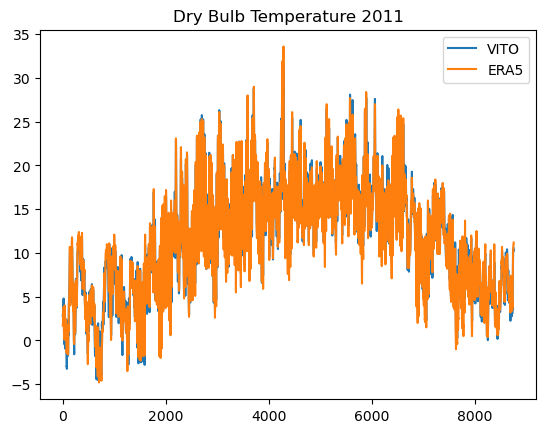

Linear Regression Formula: y = 0.98x + 0.04
R-squared: 0.98


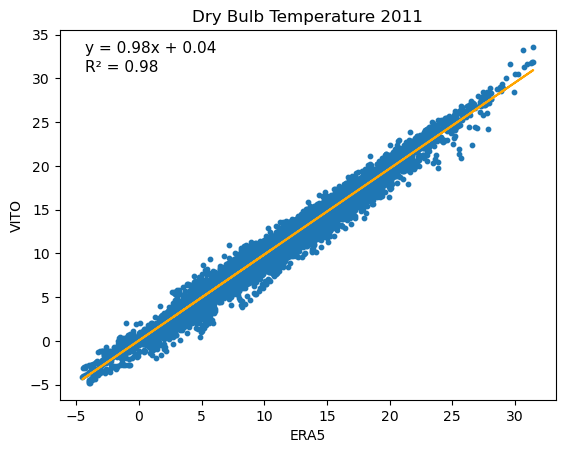

########################################################################
########################################################################


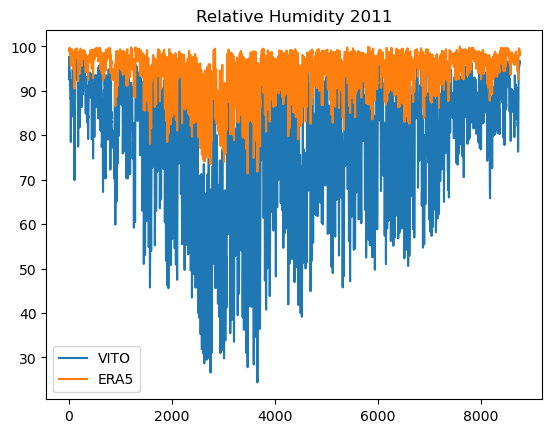

Linear Regression Formula: y = 0.32x + 69.56
R-squared: 0.90


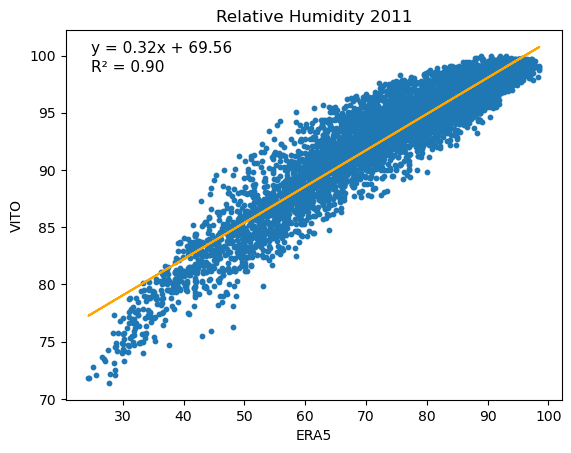

########################################################################
########################################################################


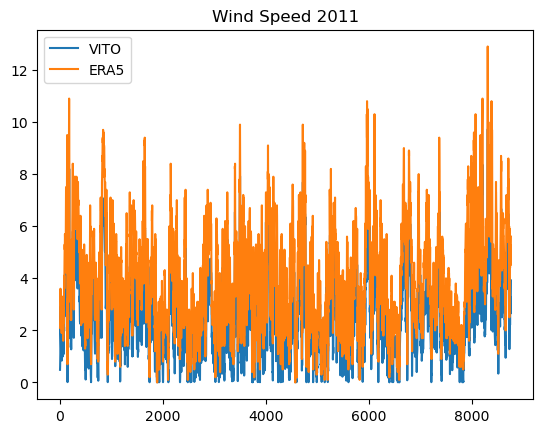

Linear Regression Formula: y = 1.17x + 1.04
R-squared: 0.93


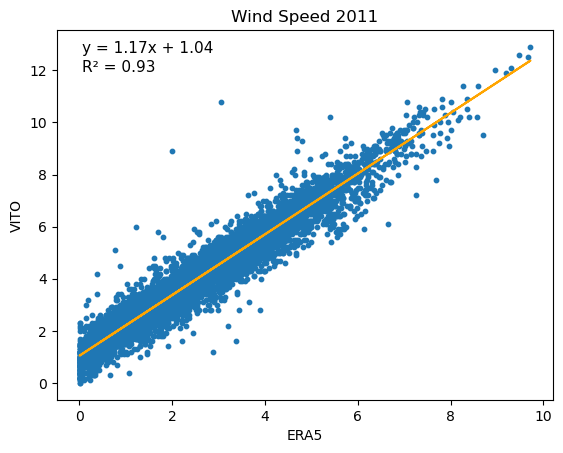

########################################################################
########################################################################


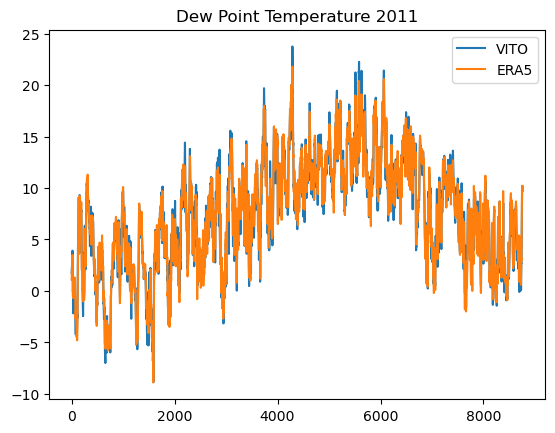

Linear Regression Formula: y = 0.98x + 0.18
R-squared: 0.97


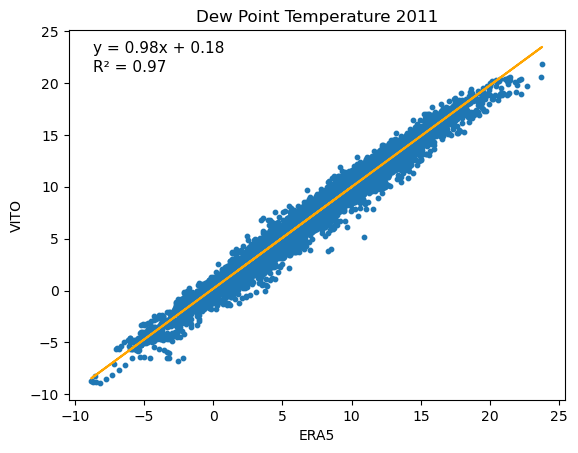

########################################################################
########################################################################


In [85]:

#x_key_list = ['DBT', 'RH', 'DPT', 'WS', 'WD','LPD', 'ASP']
#y_key_list = ['temp(C)', 'RH', 'dew(C)', 'wind', 'wind_d', 'prec(mm)', 'pres(pa)']
x_key_list = ['DBT', 'RH', 'WS', 'DPT']
y_key_list = ['temp', 'RH', 'wind', 'dew']
subject_list = ['Dry Bulb Temperature', 'Relative Humidity',  'Wind Speed', 'Dew Point Temperature']
for i in range(len(x_key_list)):
    plot_data(x_key_list[i], y_key_list[i], subject_list[i])


### generate solweig input file

##### prepare epw and solweig_hourly

In [1]:
#create input file with QGIS>>UMEP>>preprocessing>>meteorological
# based on documentation https://umep-docs.readthedocs.io/en/latest/OtherManuals/SOLWEIG.html#
# Q*      QH      QE      Qs      Qf    Wind    RH     Td     press   rain    Kdn    snow    ldown   fcld    wuh     xsmd    lai_hr  Kdiff   Kdir
#kdown/Kdn    Incoming shortwave radiation [W m-2]
#ldown    Incoming longwave radiation [W m-2]

#kdir   direct beam solar radiation (from meteorological data) [W m-2]
#kdiff   diffuse component of radiation (from meteorological data) [W m-2]
year = '2011'
#following https://climate.onebuilding.org/papers/EnergyPlus_Weather_File_Format.pdf
text = 'LOCATION,Brussels,BRU,BEL,Custom-010644,010644,50.90100,4.48400,1.0,56.1\r\
DESIGN CONDITIONS,1,2021 ASHRAE Handbook -- Fundamentals - Chapter 14 Climatic Design Information,,Heating,1,-6.1,-4.1,-9.5,1.7,-4.7,-7.2,2.1,-3.2,14.1,9.6,12.5,9.4,2.5,60,0.542,Cooling,7,9.2,29.4,20.3,27.2,19.3,25.3,18.4,21.1,27.6,20.1,25.9,19.1,24.0,3.0,60,18.8,13.7,23.7,17.9,12.9,22.6,17.0,12.2,21.6,61.1,27.8,57.6,26.0,54.3,24.1,26.9,Extremes,10.8,9.4,8.2,-8.5,33.0,2.9,1.4,-10.6,34.1,-12.3,34.9,-13.9,35.7,-16.1,36.8\r\
TYPICAL/EXTREME PERIODS,6,Summer - Week Nearest Max Temperature For Period,Extreme,6/ 8,6/14,Summer - Week Nearest Average Temperature For Period,Typical,7/20,7/26,Winter - Week Nearest Min Temperature For Period,Extreme,12/ 8,12/14,Winter - Week Nearest Average Temperature For Period,Typical,2/10,2/16,Autumn - Week Nearest Average Temperature For Period,Typical,10/20,10/26,Spring - Week Nearest Average Temperature For Period,Typical,4/ 5,4/11\r\
GROUND TEMPERATURES,3,.5,,,,9.83,6.43,4.35,3.72,4.97,7.79,11.30,14.73,17.04,17.58,16.24,13.46,2,,,,11.32,8.61,6.64,5.74,5.82,7.44,9.86,12.58,14.76,15.79,15.45,13.84,4,,,,11.92,10.07,8.53,7.67,7.16,7.87,9.31,11.15,12.86,13.93,14.14,13.42\r\
HOLIDAYS/DAYLIGHT SAVINGS,No,0,0,0\r\
COMMENTS 1,NCEI ISD - #years=[1] Period of Record='+str(year)+'-'+str(year)+'; Jan='+str(year)+'; Feb='+str(year)+'; Mar='+str(year)+'; Apr='+str(year)+'; May='+str(year)+'; Jun='+str(year)+'; Jul='+str(year)+'; Aug='+str(year)+'; Sep='+str(year)+'; Oct='+str(year)+'; Nov='+str(year)+'; Dec='+str(year)+'\r\
COMMENTS 2,Downloaded from Climate.Onebuilding.org -- Ground temps represent undisturbed earth temperatures - calculated from this weather data.\r\
DATA PERIODS,1,1,Data,Sunday,1/ 1,12/31\r'
text2 = '%iy  id  it imin   Q*      QH      QE      Qs      Qf    Wind    RH     Td     press   rain    Kdn    snow    ldown   fcld    wuh     xsmd    lai_hr  Kdiff   Kdir    Wd\r'
f_list = ['1kmE3930N3097', '1kmE3929N3101', '1kmE3929N3102', '1kmE3926N3103', '1kmE3921N3102', '1kmE3931N3096', '1kmE3931N3095', '1kmE3931N3094', '1kmE3931N3093', '1kmE3931N3090', '1kmE3930N3096', '1kmE3930N3095', '1kmE3930N3094', '1kmE3930N3093', '1kmE3930N3091', '1kmE3930N3090', '1kmE3929N3100', '1kmE3929N3099', '1kmE3929N3098', '1kmE3929N3097', '1kmE3929N3096', '1kmE3929N3095', '1kmE3929N3094', '1kmE3929N3093', '1kmE3929N3092', '1kmE3929N3091', '1kmE3929N3090', '1kmE3929N3089', '1kmE3928N3103', '1kmE3928N3102', '1kmE3928N3101', '1kmE3928N3100', '1kmE3928N3099', '1kmE3928N3098', '1kmE3928N3097', '1kmE3928N3096', '1kmE3928N3095', '1kmE3928N3094', '1kmE3928N3093', '1kmE3928N3092', '1kmE3928N3091', '1kmE3928N3090', '1kmE3928N3089', '1kmE3927N3103', '1kmE3927N3102', '1kmE3927N3101', '1kmE3927N3100', '1kmE3927N3099', '1kmE3927N3098', '1kmE3927N3097', '1kmE3927N3096', '1kmE3927N3095', '1kmE3927N3094', '1kmE3927N3093', '1kmE3927N3092', '1kmE3927N3091', '1kmE3927N3090', '1kmE3927N3089', '1kmE3926N3102', '1kmE3926N3101', '1kmE3926N3100', '1kmE3926N3099', '1kmE3926N3098', '1kmE3926N3097', '1kmE3926N3096', '1kmE3926N3095', '1kmE3926N3094', '1kmE3926N3093', '1kmE3926N3092', '1kmE3926N3091', '1kmE3926N3090', '1kmE3926N3089', '1kmE3926N3088', '1kmE3925N3102', '1kmE3925N3101', '1kmE3925N3100', '1kmE3925N3099', '1kmE3925N3098', '1kmE3925N3097', '1kmE3925N3096', '1kmE3925N3095', '1kmE3925N3094', '1kmE3925N3093', '1kmE3925N3092', '1kmE3925N3091', '1kmE3925N3090', '1kmE3925N3089', '1kmE3925N3088', '1kmE3924N3102', '1kmE3924N3101', '1kmE3924N3100', '1kmE3924N3099', '1kmE3924N3098', '1kmE3924N3097', '1kmE3924N3096', '1kmE3924N3095', '1kmE3924N3094', '1kmE3924N3093', '1kmE3924N3092', '1kmE3924N3091', '1kmE3924N3090', '1kmE3924N3089', '1kmE3923N3102', '1kmE3923N3101', '1kmE3923N3100', '1kmE3923N3099', '1kmE3923N3098', '1kmE3923N3097', '1kmE3923N3096', '1kmE3923N3095', '1kmE3923N3094', '1kmE3923N3093', '1kmE3923N3092', '1kmE3923N3091', '1kmE3923N3090', '1kmE3923N3089', '1kmE3922N3102', '1kmE3922N3101', '1kmE3922N3100', '1kmE3922N3099', '1kmE3922N3098', '1kmE3922N3097', '1kmE3922N3096', '1kmE3922N3095', '1kmE3922N3094', '1kmE3922N3093', '1kmE3922N3092', '1kmE3922N3091', '1kmE3922N3090', '1kmE3922N3089', '1kmE3921N3101', '1kmE3921N3100', '1kmE3921N3099', '1kmE3921N3098', '1kmE3921N3097', '1kmE3921N3096', '1kmE3921N3095', '1kmE3921N3094', '1kmE3921N3093', '1kmE3921N3092', '1kmE3921N3091', '1kmE3921N3090', '1kmE3921N3089', '1kmE3920N3101', '1kmE3920N3100', '1kmE3920N3099', '1kmE3920N3098', '1kmE3920N3097', '1kmE3920N3096', '1kmE3920N3095', '1kmE3920N3094', '1kmE3920N3093', '1kmE3920N3092', '1kmE3919N3099', '1kmE3919N3098', '1kmE3919N3097', '1kmE3919N3096', '1kmE3919N3095', '1kmE3919N3094', '1kmE3919N3093', '1kmE3918N3096', '1kmE3918N3095', '1kmE3918N3094', '1kmE3918N3093', '1kmE3917N3095', '1kmE3917N3094', '1kmE3916N3094', '1kmE3924N3088', '1kmE3923N3088', '1kmE3920N3090', '1kmE3920N3091', '1kmE3917N3093', '1kmE3916N3095', '1kmE3917N3096', '1kmE3918N3097', '1kmE3918N3099', '1kmE3919N3100','1kmE3919N3092']#f_list = ['1kmE3929N3099','1kmE3929N3098']
df_TMYx = df_TMYx_compare.copy()
df_txt = pd.DataFrame()
d_list = []#create day list

if int(year) % 4 == 0:
    step = 366
else:
    step = 365

for i in range(step):
    for j in range(24):
        d_list.append(i+1)

for i in range(len(y)):
    for j in range(len(x)):
        if i > 5 and i < 23:  #i > 5 and i < 24:x
            if j > 4 and j < 22: #j > 3 and i < 23:y
                df_TMYx['GHR'] = GHI #Global Horizontal Radiation
                df_TMYx['DNR'] = BNI #Direct Normal Radiation
                df_TMYx['DHR'] = DHI #Diffuse Horizontal Radiation
                df_TMYx['DBT'] = temp[:, i, j ]
                df_TMYx['DPT'] = dew[:, i, j ]
                df_TMYx['WS'] = wind[:, i, j ]
                df_TMYx['RH'] = RH[:, i, j ]
                fileName = '1kmE'+str(x[j])+'N'+str(y[i])
                if fileName in f_list:
                    print(fileName)
                    save_path = './data/meteorology/Brussels/epw/'+year+'_brussels/meteo_'+fileName+'.epw'
                    df_TMYx.to_csv(save_path, sep=',', index=False)
                    
                    with open(save_path) as f:
                        lines = f.readlines()
                    
                    lines[0] = text
                    f = open(save_path,'w')
                    for l in lines:
                            f.write(l)
                            #f.write('\r\n')
                    
                    f.close()
                    df_txt['Year'] = [int(year)]*df_TMYx['Year'].shape[0] #iy
                    df_txt['Day'] = d_list #id
                    df_txt['Hour'] = df_TMYx['Hour'] #it
                    df_txt['Minute'] = df_TMYx['Minute'] #imin
                    df_txt['Q'] = [-999.00]*df_TMYx['Year'].shape[0]#Q*
                    df_txt['QH'] = [-999.00]*df_TMYx['Year'].shape[0]#QH 
                    df_txt['QE'] = [-999.00]*df_TMYx['Year'].shape[0]#QE 
                    df_txt['Qs'] = [-999.00]*df_TMYx['Year'].shape[0]#Qs 
                    df_txt['Qf'] = [-999.00]*df_TMYx['Year'].shape[0] #Qf
                    df_txt['WS'] = np.round(df_TMYx['WS'],2) #Wind
                    df_txt['RH'] = np.round(df_TMYx['RH'],2)#RH 
                    df_txt['DBT'] = np.round(df_TMYx['DBT'],2) #Td
                    df_txt['ASP'] = np.round(df_TMYx['ASP']/1000,2) #press
                    df_txt['LPD'] = np.round(df_TMYx['LPD'],2)# rain
                    df_txt['Kdn'] = np.round(df_TMYx['GHR'],2) #GHI[:, i, j ] #Global Horizontal Radiation Kdn
                    df_txt['SD'] = np.round(df_TMYx['SD'],2) #snow
                    df_txt['HIRI'] = np.round(df_TMYx['HIRI'],2) #Horizontal Infrared Radiation Intensity  ldown
                    df_txt['fcld'] = [-999.00]*df_TMYx['Year'].shape[0]#fcld
                    df_txt['wuh'] = [-999.00]*df_TMYx['Year'].shape[0]#wuh
                    df_txt['xsmd'] = [-999.00]*df_TMYx['Year'].shape[0]#xsmd
                    df_txt['lai_hr'] = [-999.00]*df_TMYx['Year'].shape[0]#lai_hr
                    df_txt['Kdiff'] = np.round(df_TMYx['DHR'],2)#Kdiff       
                    df_txt['Kdir'] = np.round(df_TMYx['DNR'],2) #Kdir
                    df_txt['WD'] = np.round(df_TMYx['WD'],2) #Wd
                    save_path = './data/meteorology/Brussels/SOLWEIG_input/'+year+'_brussels/hourly/meteo_'+fileName+'.txt'
                    df_txt.to_csv(save_path, sep=' ', index=False)
                    
                    with open(save_path) as f:
                        lines = f.readlines()
                    
                    lines[0] = text2
                    f = open(save_path,'w')
                    for l in lines:
                            f.write(l)
                            #f.write('\r\n')
                    
                    f.close()

🌦️ Processing 178 meteorology files...
📁 Default metdata path: ./data/meteorology/Brussels/UWG_output/metdata_UMEP.txt
📁 Output directory: ./data/meteorology/Brussels/SOLWEIG_input/HeatWave_2025/
📋 1/178: UWG file not found for 1kmE3930N3097, using default data
   ✅ Created: ./data/meteorology/Brussels/SOLWEIG_input/HeatWave_2025/meteo_1kmE3930N3097_July.txt (7803 bytes)
📋 2/178: UWG file not found for 1kmE3929N3101, using default data
   ✅ Created: ./data/meteorology/Brussels/SOLWEIG_input/HeatWave_2025/meteo_1kmE3929N3101_July.txt (7803 bytes)
📋 3/178: UWG file not found for 1kmE3929N3102, using default data
   ✅ Created: ./data/meteorology/Brussels/SOLWEIG_input/HeatWave_2025/meteo_1kmE3929N3102_July.txt (7803 bytes)
📋 4/178: UWG file not found for 1kmE3926N3103, using default data
   ✅ Created: ./data/meteorology/Brussels/SOLWEIG_input/HeatWave_2025/meteo_1kmE3926N3103_July.txt (7803 bytes)
📋 5/178: UWG file not found for 1kmE3921N3102, using default data
   ✅ Created: ./data/meteo

##### prepare solweig_coldest_hottest

In [4]:
#transfer epw to txt with QGIS>>UMEP>>pre-prosessor>>meteo
f_list = ['1kmE3930N3097', '1kmE3929N3101', '1kmE3929N3102', '1kmE3926N3103', '1kmE3921N3102', '1kmE3931N3096', '1kmE3931N3095', '1kmE3931N3094', '1kmE3931N3093', '1kmE3931N3090', '1kmE3930N3096', '1kmE3930N3095', '1kmE3930N3094', '1kmE3930N3093', '1kmE3930N3091', '1kmE3930N3090', '1kmE3929N3100', '1kmE3929N3099', '1kmE3929N3098', '1kmE3929N3097', '1kmE3929N3096', '1kmE3929N3095', '1kmE3929N3094', '1kmE3929N3093', '1kmE3929N3092', '1kmE3929N3091', '1kmE3929N3090', '1kmE3929N3089', '1kmE3928N3103', '1kmE3928N3102', '1kmE3928N3101', '1kmE3928N3100', '1kmE3928N3099', '1kmE3928N3098', '1kmE3928N3097', '1kmE3928N3096', '1kmE3928N3095', '1kmE3928N3094', '1kmE3928N3093', '1kmE3928N3092', '1kmE3928N3091', '1kmE3928N3090', '1kmE3928N3089', '1kmE3927N3103', '1kmE3927N3102', '1kmE3927N3101', '1kmE3927N3100', '1kmE3927N3099', '1kmE3927N3098', '1kmE3927N3097', '1kmE3927N3096', '1kmE3927N3095', '1kmE3927N3094', '1kmE3927N3093', '1kmE3927N3092', '1kmE3927N3091', '1kmE3927N3090', '1kmE3927N3089', '1kmE3926N3102', '1kmE3926N3101', '1kmE3926N3100', '1kmE3926N3099', '1kmE3926N3098', '1kmE3926N3097', '1kmE3926N3096', '1kmE3926N3095', '1kmE3926N3094', '1kmE3926N3093', '1kmE3926N3092', '1kmE3926N3091', '1kmE3926N3090', '1kmE3926N3089', '1kmE3926N3088', '1kmE3925N3102', '1kmE3925N3101', '1kmE3925N3100', '1kmE3925N3099', '1kmE3925N3098', '1kmE3925N3097', '1kmE3925N3096', '1kmE3925N3095', '1kmE3925N3094', '1kmE3925N3093', '1kmE3925N3092', '1kmE3925N3091', '1kmE3925N3090', '1kmE3925N3089', '1kmE3925N3088', '1kmE3924N3102', '1kmE3924N3101', '1kmE3924N3100', '1kmE3924N3099', '1kmE3924N3098', '1kmE3924N3097', '1kmE3924N3096', '1kmE3924N3095', '1kmE3924N3094', '1kmE3924N3093', '1kmE3924N3092', '1kmE3924N3091', '1kmE3924N3090', '1kmE3924N3089', '1kmE3923N3102', '1kmE3923N3101', '1kmE3923N3100', '1kmE3923N3099', '1kmE3923N3098', '1kmE3923N3097', '1kmE3923N3096', '1kmE3923N3095', '1kmE3923N3094', '1kmE3923N3093', '1kmE3923N3092', '1kmE3923N3091', '1kmE3923N3090', '1kmE3923N3089', '1kmE3922N3102', '1kmE3922N3101', '1kmE3922N3100', '1kmE3922N3099', '1kmE3922N3098', '1kmE3922N3097', '1kmE3922N3096', '1kmE3922N3095', '1kmE3922N3094', '1kmE3922N3093', '1kmE3922N3092', '1kmE3922N3091', '1kmE3922N3090', '1kmE3922N3089', '1kmE3921N3101', '1kmE3921N3100', '1kmE3921N3099', '1kmE3921N3098', '1kmE3921N3097', '1kmE3921N3096', '1kmE3921N3095', '1kmE3921N3094', '1kmE3921N3093', '1kmE3921N3092', '1kmE3921N3091', '1kmE3921N3090', '1kmE3921N3089', '1kmE3920N3101', '1kmE3920N3100', '1kmE3920N3099', '1kmE3920N3098', '1kmE3920N3097', '1kmE3920N3096', '1kmE3920N3095', '1kmE3920N3094', '1kmE3920N3093', '1kmE3920N3092', '1kmE3919N3099', '1kmE3919N3098', '1kmE3919N3097', '1kmE3919N3096', '1kmE3919N3095', '1kmE3919N3094', '1kmE3919N3093', '1kmE3918N3096', '1kmE3918N3095', '1kmE3918N3094', '1kmE3918N3093', '1kmE3917N3095', '1kmE3917N3094', '1kmE3916N3094', '1kmE3924N3088', '1kmE3923N3088', '1kmE3920N3090', '1kmE3920N3091', '1kmE3917N3093', '1kmE3916N3095', '1kmE3917N3096', '1kmE3918N3097', '1kmE3918N3099', '1kmE3919N3100', '1kmE3919N3092']

year = '2011'
DoY1, DoY2 = 80, 264  #30, 179 Two specific Days of Year to extract

HEADER = '%iy  id  it imin   Q*      QH      QE      Qs      Qf    Wind    RH     Td     press   rain    Kdn    snow    ldown   fcld    wuh     xsmd    lai_hr  Kdiff   Kdir    Wd\r'
int_cols  = ['%iy', 'id', 'it', 'imin']
float_cols = ['Q*', 'QH', 'QE', 'Qs', 'Qf', 'Wind', 'RH', 'Td', 'press', 'rain', 'Kdn', 'snow', 'ldown', 'fcld', 'wuh', 'xsmd', 'lai_hr', 'Kdiff', 'Kdir', 'Wd']

def write_solweig_txt(df, save_path, header):
    """Save dataframe to SOLWEIG-format text file with custom header."""
    df.to_csv(save_path, sep=' ', index=False)
    with open(save_path, 'r') as f:
        lines = f.readlines()
    lines[0] = header
    with open(save_path, 'w') as f:
        f.writelines(lines)

for file_name in f_list:
    print(file_name)

    # --- Read hourly data ---
    df = pd.read_csv(
        f'./data/meteorology/Brussels/SOLWEIG_input/{year}_brussels/hourly/meteo_{file_name}.txt',
        sep=r'\s+', skiprows=0
    )
    df['%iy'] = int(year)

    # --- Save corrected full hourly file (same as original) ---
    save_path_hourly = f'./data/meteorology/Brussels/SOLWEIG_input/{year}_brussels/hourly/meteo_{file_name}_2.txt'
    write_solweig_txt(df, save_path_hourly, HEADER)

    # --- Filter: keep only DoY1 and DoY2, hours 8–23 ---
    mask = (
        df['id'].isin([DoY1, DoY2]) &        # only the two target days
        (df['it'] >= 8) &                     # hour 8 onwards
        (df['it'] <= 23)                      # up to hour 23
    )
    df_filtered = df[mask].copy().reset_index(drop=True)

    # --- Cast types ---
    for col in float_cols:
        df_filtered[col] = np.round(df_filtered[col], 2)
    for col in int_cols:
        df_filtered[col] = df_filtered[col].astype(int)

    print(f"  Filtered rows (DoY {DoY1} & {DoY2}, hours 8-23): {len(df_filtered)}")  # Should be 32 rows (2 days × 16 hours)

    # --- Save filtered hourly file ---
    save_path_filtered = f'./data/meteorology/Brussels/SOLWEIG_input/{year}_brussels/cold_hot/meteo_{file_name}_DoY{DoY1}_{DoY2}_hourly.txt'
    write_solweig_txt(df_filtered, save_path_filtered, HEADER)

1kmE3930N3097
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3929N3101
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3929N3102
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3926N3103
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3921N3102
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3931N3096
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3931N3095
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3931N3094
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3931N3093
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3931N3090
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3930N3096
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3930N3095
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3930N3094
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3930N3093
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3930N3091
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3930N3090
  Filtered rows (DoY 80 & 264, hours 8-23): 32
1kmE3929N3100
  Filtered

In [5]:
year = 2011
# Define the starting date and time
start_datetime = dt.datetime(year, 1, 1, 0, 0)
end_datetime = start_datetime + dt.timedelta(days=178)
print(end_datetime)

2011-06-28 00:00:00


##### prepare solweig_day_night (8 hr)

In [37]:
#transfer epw to txt with QGIS>>UMEP>>pre-prosessor>>meteo
#, names=['Year', 'Month', 'Day', 'Hour', 'Minute', 'Q*', 'QH', 'QE', 'Qs', 'Qf', 'Wind', 'RH', 'Td', 'press', 'rain', 'Kdn', 'snow', 'ldown', 'fcld', 'wuh', 'xsmd', 'lai_hr', 'Kdiff', 'Kdir', 'Wd']
#f_list = ['1kmE3931N3096','1kmE3931N3095','1kmE3931N3094','1kmE3931N3093','1kmE3931N3090','1kmE3930N3096','1kmE3930N3095','1kmE3930N3094','1kmE3930N3093','1kmE3930N3091','1kmE3930N3090','1kmE3929N3100','1kmE3929N3097','1kmE3929N3096','1kmE3929N3095','1kmE3929N3094','1kmE3929N3093','1kmE3929N3092','1kmE3929N3091','1kmE3929N3090','1kmE3929N3089','1kmE3928N3103','1kmE3928N3102','1kmE3928N3101','1kmE3928N3100','1kmE3928N3099','1kmE3928N3098','1kmE3928N3097','1kmE3928N3096','1kmE3928N3095','1kmE3928N3094','1kmE3928N3093','1kmE3928N3092','1kmE3928N3091','1kmE3928N3090','1kmE3928N3089','1kmE3927N3103','1kmE3927N3102','1kmE3927N3101','1kmE3927N3100','1kmE3927N3099','1kmE3927N3098','1kmE3927N3097','1kmE3927N3096','1kmE3927N3095','1kmE3927N3094','1kmE3927N3093','1kmE3927N3092','1kmE3927N3091','1kmE3927N3090','1kmE3927N3089','1kmE3926N3102','1kmE3926N3101','1kmE3926N3100','1kmE3926N3099','1kmE3926N3098','1kmE3926N3097','1kmE3926N3096','1kmE3926N3095','1kmE3926N3094','1kmE3926N3093','1kmE3926N3092','1kmE3926N3091','1kmE3926N3090','1kmE3926N3089','1kmE3926N3088','1kmE3925N3102','1kmE3925N3101','1kmE3925N3100','1kmE3925N3099','1kmE3925N3098','1kmE3925N3097','1kmE3925N3096','1kmE3925N3095','1kmE3925N3094','1kmE3925N3093','1kmE3925N3092','1kmE3925N3091','1kmE3925N3090','1kmE3925N3089','1kmE3925N3088','1kmE3924N3102','1kmE3924N3101','1kmE3924N3100','1kmE3924N3099','1kmE3924N3098','1kmE3924N3097','1kmE3924N3096','1kmE3924N3095','1kmE3924N3094','1kmE3924N3093','1kmE3924N3092','1kmE3924N3091','1kmE3924N3090','1kmE3924N3089','1kmE3923N3102','1kmE3923N3101','1kmE3923N3100','1kmE3923N3099','1kmE3923N3098','1kmE3923N3097','1kmE3923N3096','1kmE3923N3095','1kmE3923N3094','1kmE3923N3093','1kmE3923N3092','1kmE3923N3091','1kmE3923N3090','1kmE3923N3089','1kmE3922N3102','1kmE3922N3101','1kmE3922N3100','1kmE3922N3099','1kmE3922N3098','1kmE3922N3097','1kmE3922N3096','1kmE3922N3095','1kmE3922N3094','1kmE3922N3093','1kmE3922N3092','1kmE3922N3091','1kmE3922N3090','1kmE3922N3089','1kmE3921N3101','1kmE3921N3100','1kmE3921N3099','1kmE3921N3098','1kmE3921N3097','1kmE3921N3096','1kmE3921N3095','1kmE3921N3094','1kmE3921N3093','1kmE3921N3092','1kmE3921N3091','1kmE3921N3090','1kmE3921N3089','1kmE3920N3101','1kmE3920N3100','1kmE3920N3099','1kmE3920N3098','1kmE3920N3097','1kmE3920N3096','1kmE3920N3095','1kmE3920N3094','1kmE3920N3093','1kmE3920N3092','1kmE3919N3099','1kmE3919N3098','1kmE3919N3097','1kmE3919N3096','1kmE3919N3095','1kmE3919N3094','1kmE3919N3093','1kmE3918N3096','1kmE3918N3095','1kmE3918N3094','1kmE3918N3093','1kmE3917N3095','1kmE3917N3094','1kmE3916N3094']
f_list = ['1kmE3930N3097', '1kmE3929N3101', '1kmE3929N3102', '1kmE3926N3103', '1kmE3921N3102', '1kmE3931N3096', '1kmE3931N3095', '1kmE3931N3094', '1kmE3931N3093', '1kmE3931N3090', '1kmE3930N3096', '1kmE3930N3095', '1kmE3930N3094', '1kmE3930N3093', '1kmE3930N3091', '1kmE3930N3090', '1kmE3929N3100', '1kmE3929N3099', '1kmE3929N3098', '1kmE3929N3097', '1kmE3929N3096', '1kmE3929N3095', '1kmE3929N3094', '1kmE3929N3093', '1kmE3929N3092', '1kmE3929N3091', '1kmE3929N3090', '1kmE3929N3089', '1kmE3928N3103', '1kmE3928N3102', '1kmE3928N3101', '1kmE3928N3100', '1kmE3928N3099', '1kmE3928N3098', '1kmE3928N3097', '1kmE3928N3096', '1kmE3928N3095', '1kmE3928N3094', '1kmE3928N3093', '1kmE3928N3092', '1kmE3928N3091', '1kmE3928N3090', '1kmE3928N3089', '1kmE3927N3103', '1kmE3927N3102', '1kmE3927N3101', '1kmE3927N3100', '1kmE3927N3099', '1kmE3927N3098', '1kmE3927N3097', '1kmE3927N3096', '1kmE3927N3095', '1kmE3927N3094', '1kmE3927N3093', '1kmE3927N3092', '1kmE3927N3091', '1kmE3927N3090', '1kmE3927N3089', '1kmE3926N3102', '1kmE3926N3101', '1kmE3926N3100', '1kmE3926N3099', '1kmE3926N3098', '1kmE3926N3097', '1kmE3926N3096', '1kmE3926N3095', '1kmE3926N3094', '1kmE3926N3093', '1kmE3926N3092', '1kmE3926N3091', '1kmE3926N3090', '1kmE3926N3089', '1kmE3926N3088', '1kmE3925N3102', '1kmE3925N3101', '1kmE3925N3100', '1kmE3925N3099', '1kmE3925N3098', '1kmE3925N3097', '1kmE3925N3096', '1kmE3925N3095', '1kmE3925N3094', '1kmE3925N3093', '1kmE3925N3092', '1kmE3925N3091', '1kmE3925N3090', '1kmE3925N3089', '1kmE3925N3088', '1kmE3924N3102', '1kmE3924N3101', '1kmE3924N3100', '1kmE3924N3099', '1kmE3924N3098', '1kmE3924N3097', '1kmE3924N3096', '1kmE3924N3095', '1kmE3924N3094', '1kmE3924N3093', '1kmE3924N3092', '1kmE3924N3091', '1kmE3924N3090', '1kmE3924N3089', '1kmE3923N3102', '1kmE3923N3101', '1kmE3923N3100', '1kmE3923N3099', '1kmE3923N3098', '1kmE3923N3097', '1kmE3923N3096', '1kmE3923N3095', '1kmE3923N3094', '1kmE3923N3093', '1kmE3923N3092', '1kmE3923N3091', '1kmE3923N3090', '1kmE3923N3089', '1kmE3922N3102', '1kmE3922N3101', '1kmE3922N3100', '1kmE3922N3099', '1kmE3922N3098', '1kmE3922N3097', '1kmE3922N3096', '1kmE3922N3095', '1kmE3922N3094', '1kmE3922N3093', '1kmE3922N3092', '1kmE3922N3091', '1kmE3922N3090', '1kmE3922N3089', '1kmE3921N3101', '1kmE3921N3100', '1kmE3921N3099', '1kmE3921N3098', '1kmE3921N3097', '1kmE3921N3096', '1kmE3921N3095', '1kmE3921N3094', '1kmE3921N3093', '1kmE3921N3092', '1kmE3921N3091', '1kmE3921N3090', '1kmE3921N3089', '1kmE3920N3101', '1kmE3920N3100', '1kmE3920N3099', '1kmE3920N3098', '1kmE3920N3097', '1kmE3920N3096', '1kmE3920N3095', '1kmE3920N3094', '1kmE3920N3093', '1kmE3920N3092', '1kmE3919N3099', '1kmE3919N3098', '1kmE3919N3097', '1kmE3919N3096', '1kmE3919N3095', '1kmE3919N3094', '1kmE3919N3093', '1kmE3918N3096', '1kmE3918N3095', '1kmE3918N3094', '1kmE3918N3093', '1kmE3917N3095', '1kmE3917N3094', '1kmE3916N3094', '1kmE3924N3088', '1kmE3923N3088', '1kmE3920N3090', '1kmE3920N3091', '1kmE3917N3093', '1kmE3916N3095', '1kmE3917N3096', '1kmE3918N3097', '1kmE3918N3099', '1kmE3919N3100','1kmE3919N3092']#f_list = ['1kmE3929N3099','1kmE3929N3098']
print(year)
for file_name in f_list:
    print(file_name)
    df_SOLWEIG = pd.read_csv('./data/meteorology/Brussels/SOLWEIG_input/'+year+'_brussels/hourly/meteo_'+file_name+'.txt', sep = '\s+', skiprows=0)
    #print(df_station.head())
    df_SOLWEIG['%iy'] = [int(year)]*df_SOLWEIG['%iy'].shape[0]
    '''
    hour_list = []
    for i in range(24):
        hour_list.append(i)
    df_SOLWEIG['it'] = hour_list*int(df_SOLWEIG['%iy'].shape[0]/24)
    '''
    save_path = './data/meteorology/Brussels/SOLWEIG_input/'+year+'_brussels/hourly/meteo_'+file_name+'_2.txt'
    df_SOLWEIG.to_csv(save_path, sep = ' ', index=False)
    with open(save_path) as f:
        lines = f.readlines()
        #print(lines[0])
    lines[0] = '%iy  id  it imin   Q*      QH      QE      Qs      Qf    Wind    RH     Td     press   rain    Kdn    snow    ldown   fcld    wuh     xsmd    lai_hr  Kdiff   Kdir    Wd\r'
    #print(lines[0])
    #print(lines[1])
    f = open(save_path,'w')
    for l in lines:
        f.write(l)
                    
    f.close()
    df_SOLWEIG_day = df_SOLWEIG.copy()
    df_SOLWEIG_night = df_SOLWEIG.copy()
    drop_list = []
    for i in range(len(df_SOLWEIG_day)):
        if (i % 24 < 7) or (i % 24 == 23):
            #print(drop_list)#if (i % 24 < 7) or (i % 24 == 23): #index starts with 0
            df_SOLWEIG_day = df_SOLWEIG_day.drop(i)

    df_SOLWEIG_day = df_SOLWEIG_day.reset_index(drop=True)
    #print(df_SOLWEIG_day.head())
    df_SOLWEIG_day = df_SOLWEIG_day.groupby(df_SOLWEIG_day.index // 8).mean()
    print(df_SOLWEIG_day.shape)

    int_list=['%iy', 	'id', 	'it', 	'imin']
    float_list=[ 'Q*', 'QH', 'QE', 'Qs', 'Qf', 'Wind', 'RH', 'Td', 'press', 'rain', 'Kdn', 'snow', 'ldown', 'fcld', 'wuh', 'xsmd', 'lai_hr', 'Kdiff', 'Kdir', 'Wd']
    start_datetime = dt.datetime(int(year), 1, 1, 10, 0)
    for i in range(len(df_SOLWEIG_day)):
        end_datetime = start_datetime + dt.timedelta(hours=i*12)
        df_SOLWEIG_day.loc[i, '%iy'] = int(str(end_datetime)[:4])
        df_SOLWEIG_day.loc[i, 'id'] = int(end_datetime.timetuple().tm_yday)
        if i % 2 == 1:
            df_SOLWEIG_day.loc[i, 'it'] = int(str(end_datetime)[11:13])-2
        else:
            df_SOLWEIG_day.loc[i, 'it'] = int(str(end_datetime)[11:13])+2
        df_SOLWEIG_day.loc[i, 'imin'] = int(df_SOLWEIG_day.loc[i, 'imin'])
    
    for col in float_list:
        df_SOLWEIG_day[col] = np.round(df_SOLWEIG_day[col],2)
        
    for col in int_list:
        df_SOLWEIG_day = df_SOLWEIG_day.astype({col:'int'})
    
    save_path = './data/meteorology/Brussels/SOLWEIG_input/'+year+'_brussels/day_night/meteo_'+file_name+'_DayNight.txt'
    df_SOLWEIG_day.to_csv(save_path, sep = ' ', index=False)
    with open(save_path) as f:
        lines = f.readlines()
        #print(lines[0])
    lines[0] = '%iy  id  it imin   Q*      QH      QE      Qs      Qf    Wind    RH     Td     press   rain    Kdn    snow    ldown   fcld    wuh     xsmd    lai_hr  Kdiff   Kdir    Wd\r'
    #print(lines[0])
    #print(lines[1])
    f = open(save_path,'w')
    for l in lines:
        f.write(l)
                    
    f.close()

2010
1kmE3930N3097
(730, 24)
1kmE3929N3101
(730, 24)
1kmE3929N3102
(730, 24)
1kmE3926N3103
(730, 24)
1kmE3921N3102
(730, 24)
1kmE3931N3096
(730, 24)
1kmE3931N3095
(730, 24)
1kmE3931N3094
(730, 24)
1kmE3931N3093
(730, 24)
1kmE3931N3090
(730, 24)
1kmE3930N3096
(730, 24)
1kmE3930N3095
(730, 24)
1kmE3930N3094
(730, 24)
1kmE3930N3093
(730, 24)
1kmE3930N3091
(730, 24)
1kmE3930N3090
(730, 24)
1kmE3929N3100
(730, 24)
1kmE3929N3099
(730, 24)
1kmE3929N3098
(730, 24)
1kmE3929N3097
(730, 24)
1kmE3929N3096
(730, 24)
1kmE3929N3095
(730, 24)
1kmE3929N3094
(730, 24)
1kmE3929N3093
(730, 24)
1kmE3929N3092
(730, 24)
1kmE3929N3091
(730, 24)
1kmE3929N3090
(730, 24)
1kmE3929N3089
(730, 24)
1kmE3928N3103
(730, 24)
1kmE3928N3102
(730, 24)
1kmE3928N3101
(730, 24)
1kmE3928N3100
(730, 24)
1kmE3928N3099
(730, 24)
1kmE3928N3098
(730, 24)
1kmE3928N3097
(730, 24)
1kmE3928N3096
(730, 24)
1kmE3928N3095
(730, 24)
1kmE3928N3094
(730, 24)
1kmE3928N3093
(730, 24)
1kmE3928N3092
(730, 24)
1kmE3928N3091
(730, 24)
1kmE3928N30

##### prepare solweig_day_night_window
lunck break exprosure

In [2]:
#transfer epw to txt with QGIS>>UMEP>>pre-prosessor>>meteo
#, names=['Year', 'Month', 'Day', 'Hour', 'Minute', 'Q*', 'QH', 'QE', 'Qs', 'Qf', 'Wind', 'RH', 'Td', 'press', 'rain', 'Kdn', 'snow', 'ldown', 'fcld', 'wuh', 'xsmd', 'lai_hr', 'Kdiff', 'Kdir', 'Wd']
#f_list = ['1kmE3931N3096','1kmE3931N3095','1kmE3931N3094','1kmE3931N3093','1kmE3931N3090','1kmE3930N3096','1kmE3930N3095','1kmE3930N3094','1kmE3930N3093','1kmE3930N3091','1kmE3930N3090','1kmE3929N3100','1kmE3929N3097','1kmE3929N3096','1kmE3929N3095','1kmE3929N3094','1kmE3929N3093','1kmE3929N3092','1kmE3929N3091','1kmE3929N3090','1kmE3929N3089','1kmE3928N3103','1kmE3928N3102','1kmE3928N3101','1kmE3928N3100','1kmE3928N3099','1kmE3928N3098','1kmE3928N3097','1kmE3928N3096','1kmE3928N3095','1kmE3928N3094','1kmE3928N3093','1kmE3928N3092','1kmE3928N3091','1kmE3928N3090','1kmE3928N3089','1kmE3927N3103','1kmE3927N3102','1kmE3927N3101','1kmE3927N3100','1kmE3927N3099','1kmE3927N3098','1kmE3927N3097','1kmE3927N3096','1kmE3927N3095','1kmE3927N3094','1kmE3927N3093','1kmE3927N3092','1kmE3927N3091','1kmE3927N3090','1kmE3927N3089','1kmE3926N3102','1kmE3926N3101','1kmE3926N3100','1kmE3926N3099','1kmE3926N3098','1kmE3926N3097','1kmE3926N3096','1kmE3926N3095','1kmE3926N3094','1kmE3926N3093','1kmE3926N3092','1kmE3926N3091','1kmE3926N3090','1kmE3926N3089','1kmE3926N3088','1kmE3925N3102','1kmE3925N3101','1kmE3925N3100','1kmE3925N3099','1kmE3925N3098','1kmE3925N3097','1kmE3925N3096','1kmE3925N3095','1kmE3925N3094','1kmE3925N3093','1kmE3925N3092','1kmE3925N3091','1kmE3925N3090','1kmE3925N3089','1kmE3925N3088','1kmE3924N3102','1kmE3924N3101','1kmE3924N3100','1kmE3924N3099','1kmE3924N3098','1kmE3924N3097','1kmE3924N3096','1kmE3924N3095','1kmE3924N3094','1kmE3924N3093','1kmE3924N3092','1kmE3924N3091','1kmE3924N3090','1kmE3924N3089','1kmE3923N3102','1kmE3923N3101','1kmE3923N3100','1kmE3923N3099','1kmE3923N3098','1kmE3923N3097','1kmE3923N3096','1kmE3923N3095','1kmE3923N3094','1kmE3923N3093','1kmE3923N3092','1kmE3923N3091','1kmE3923N3090','1kmE3923N3089','1kmE3922N3102','1kmE3922N3101','1kmE3922N3100','1kmE3922N3099','1kmE3922N3098','1kmE3922N3097','1kmE3922N3096','1kmE3922N3095','1kmE3922N3094','1kmE3922N3093','1kmE3922N3092','1kmE3922N3091','1kmE3922N3090','1kmE3922N3089','1kmE3921N3101','1kmE3921N3100','1kmE3921N3099','1kmE3921N3098','1kmE3921N3097','1kmE3921N3096','1kmE3921N3095','1kmE3921N3094','1kmE3921N3093','1kmE3921N3092','1kmE3921N3091','1kmE3921N3090','1kmE3921N3089','1kmE3920N3101','1kmE3920N3100','1kmE3920N3099','1kmE3920N3098','1kmE3920N3097','1kmE3920N3096','1kmE3920N3095','1kmE3920N3094','1kmE3920N3093','1kmE3920N3092','1kmE3919N3099','1kmE3919N3098','1kmE3919N3097','1kmE3919N3096','1kmE3919N3095','1kmE3919N3094','1kmE3919N3093','1kmE3918N3096','1kmE3918N3095','1kmE3918N3094','1kmE3918N3093','1kmE3917N3095','1kmE3917N3094','1kmE3916N3094']
f_list = ['1kmE3930N3097', '1kmE3929N3101', '1kmE3929N3102', '1kmE3926N3103', '1kmE3921N3102', '1kmE3931N3096', '1kmE3931N3095', '1kmE3931N3094', '1kmE3931N3093', '1kmE3931N3090', '1kmE3930N3096', '1kmE3930N3095', '1kmE3930N3094', '1kmE3930N3093', '1kmE3930N3091', '1kmE3930N3090', '1kmE3929N3100', '1kmE3929N3099', '1kmE3929N3098', '1kmE3929N3097', '1kmE3929N3096', '1kmE3929N3095', '1kmE3929N3094', '1kmE3929N3093', '1kmE3929N3092', '1kmE3929N3091', '1kmE3929N3090', '1kmE3929N3089', '1kmE3928N3103', '1kmE3928N3102', '1kmE3928N3101', '1kmE3928N3100', '1kmE3928N3099', '1kmE3928N3098', '1kmE3928N3097', '1kmE3928N3096', '1kmE3928N3095', '1kmE3928N3094', '1kmE3928N3093', '1kmE3928N3092', '1kmE3928N3091', '1kmE3928N3090', '1kmE3928N3089', '1kmE3927N3103', '1kmE3927N3102', '1kmE3927N3101', '1kmE3927N3100', '1kmE3927N3099', '1kmE3927N3098', '1kmE3927N3097', '1kmE3927N3096', '1kmE3927N3095', '1kmE3927N3094', '1kmE3927N3093', '1kmE3927N3092', '1kmE3927N3091', '1kmE3927N3090', '1kmE3927N3089', '1kmE3926N3102', '1kmE3926N3101', '1kmE3926N3100', '1kmE3926N3099', '1kmE3926N3098', '1kmE3926N3097', '1kmE3926N3096', '1kmE3926N3095', '1kmE3926N3094', '1kmE3926N3093', '1kmE3926N3092', '1kmE3926N3091', '1kmE3926N3090', '1kmE3926N3089', '1kmE3926N3088', '1kmE3925N3102', '1kmE3925N3101', '1kmE3925N3100', '1kmE3925N3099', '1kmE3925N3098', '1kmE3925N3097', '1kmE3925N3096', '1kmE3925N3095', '1kmE3925N3094', '1kmE3925N3093', '1kmE3925N3092', '1kmE3925N3091', '1kmE3925N3090', '1kmE3925N3089', '1kmE3925N3088', '1kmE3924N3102', '1kmE3924N3101', '1kmE3924N3100', '1kmE3924N3099', '1kmE3924N3098', '1kmE3924N3097', '1kmE3924N3096', '1kmE3924N3095', '1kmE3924N3094', '1kmE3924N3093', '1kmE3924N3092', '1kmE3924N3091', '1kmE3924N3090', '1kmE3924N3089', '1kmE3923N3102', '1kmE3923N3101', '1kmE3923N3100', '1kmE3923N3099', '1kmE3923N3098', '1kmE3923N3097', '1kmE3923N3096', '1kmE3923N3095', '1kmE3923N3094', '1kmE3923N3093', '1kmE3923N3092', '1kmE3923N3091', '1kmE3923N3090', '1kmE3923N3089', '1kmE3922N3102', '1kmE3922N3101', '1kmE3922N3100', '1kmE3922N3099', '1kmE3922N3098', '1kmE3922N3097', '1kmE3922N3096', '1kmE3922N3095', '1kmE3922N3094', '1kmE3922N3093', '1kmE3922N3092', '1kmE3922N3091', '1kmE3922N3090', '1kmE3922N3089', '1kmE3921N3101', '1kmE3921N3100', '1kmE3921N3099', '1kmE3921N3098', '1kmE3921N3097', '1kmE3921N3096', '1kmE3921N3095', '1kmE3921N3094', '1kmE3921N3093', '1kmE3921N3092', '1kmE3921N3091', '1kmE3921N3090', '1kmE3921N3089', '1kmE3920N3101', '1kmE3920N3100', '1kmE3920N3099', '1kmE3920N3098', '1kmE3920N3097', '1kmE3920N3096', '1kmE3920N3095', '1kmE3920N3094', '1kmE3920N3093', '1kmE3920N3092', '1kmE3919N3099', '1kmE3919N3098', '1kmE3919N3097', '1kmE3919N3096', '1kmE3919N3095', '1kmE3919N3094', '1kmE3919N3093', '1kmE3918N3096', '1kmE3918N3095', '1kmE3918N3094', '1kmE3918N3093', '1kmE3917N3095', '1kmE3917N3094', '1kmE3916N3094', '1kmE3924N3088', '1kmE3923N3088', '1kmE3920N3090', '1kmE3920N3091', '1kmE3917N3093', '1kmE3916N3095', '1kmE3917N3096', '1kmE3918N3097', '1kmE3918N3099', '1kmE3919N3100','1kmE3919N3092']#f_list = ['1kmE3929N3099','1kmE3929N3098']
for file_name in f_list:
    print(file_name)
    df_SOLWEIG = pd.read_csv('./data/meteorology/Brussels/SOLWEIG_input/hourly/meteo_'+file_name+'.txt', sep = '\s+', skiprows=0)
    #print(df_station.head())
    df_SOLWEIG['%iy'] = [int(year)]*df_SOLWEIG['%iy'].shape[0]
    '''
    hour_list = []
    for i in range(24):
        hour_list.append(i)
    df_SOLWEIG['it'] = hour_list*int(df_SOLWEIG['%iy'].shape[0]/24)
    '''
    save_path = './data/meteorology/Brussels/SOLWEIG_input/hourly/meteo_'+file_name+'_2.txt'
    df_SOLWEIG.to_csv(save_path, sep = ' ', index=False)
    with open(save_path) as f:
        lines = f.readlines()
        #print(lines[0])
    lines[0] = '%iy  id  it imin   Q*      QH      QE      Qs      Qf    Wind    RH     Td     press   rain    Kdn    snow    ldown   fcld    wuh     xsmd    lai_hr  Kdiff   Kdir    Wd\r'
    #print(lines[0])
    #print(lines[1])
    f = open(save_path,'w')
    for l in lines:
        f.write(l)
                    
    f.close()
    df_SOLWEIG_day = df_SOLWEIG.copy()
    df_SOLWEIG_night = df_SOLWEIG.copy()
    drop_list = []
    for i in range(len(df_SOLWEIG_day)):
        if (i % 24 < 11) or (i % 24 > 13):
            #print(drop_list)#if (i % 24 < 7) or (i % 24 == 23): #index starts with 0
            df_SOLWEIG_day = df_SOLWEIG_day.drop(i)

    df_SOLWEIG_day = df_SOLWEIG_day.reset_index(drop=True)
    #print(df_SOLWEIG_day.head())
    df_SOLWEIG_day = df_SOLWEIG_day.groupby(df_SOLWEIG_day.index // 3).mean()
    print(df_SOLWEIG_day.shape)

    int_list=['%iy', 	'id', 	'it', 	'imin']
    float_list=[ 'Q*', 'QH', 'QE', 'Qs', 'Qf', 'Wind', 'RH', 'Td', 'press', 'rain', 'Kdn', 'snow', 'ldown', 'fcld', 'wuh', 'xsmd', 'lai_hr', 'Kdiff', 'Kdir', 'Wd']
    start_datetime = dt.datetime(int(year), 1, 1, 13, 0)
    for i in range(len(df_SOLWEIG_day)):
        end_datetime = start_datetime + dt.timedelta(hours=i*24)
        df_SOLWEIG_day.loc[i, '%iy'] = int(str(end_datetime)[:4])
        df_SOLWEIG_day.loc[i, 'id'] = int(end_datetime.timetuple().tm_yday)
        df_SOLWEIG_day.loc[i, 'it'] = int(str(end_datetime)[11:13])
        df_SOLWEIG_day.loc[i, 'imin'] = int(df_SOLWEIG_day.loc[i, 'imin'])
    
    for col in float_list:
        df_SOLWEIG_day[col] = np.round(df_SOLWEIG_day[col],2)
        
    for col in int_list:
        df_SOLWEIG_day = df_SOLWEIG_day.astype({col:'int'})
    
    save_path = './data/meteorology/Brussels/SOLWEIG_input/window/meteo_'+file_name+'_lunch.txt'
    df_SOLWEIG_day.to_csv(save_path, sep = ' ', index=False)
    with open(save_path) as f:
        lines = f.readlines()
        #print(lines[0])
    lines[0] = '%iy  id  it imin   Q*      QH      QE      Qs      Qf    Wind    RH     Td     press   rain    Kdn    snow    ldown   fcld    wuh     xsmd    lai_hr  Kdiff   Kdir    Wd\r'
    #print(lines[0])
    #print(lines[1])
    f = open(save_path,'w')
    for l in lines:
        f.write(l)
                    
    f.close()

1kmE3930N3097
(365, 24)
1kmE3929N3101
(365, 24)
1kmE3929N3102
(365, 24)
1kmE3926N3103
(365, 24)
1kmE3921N3102
(365, 24)
1kmE3931N3096
(365, 24)
1kmE3931N3095
(365, 24)
1kmE3931N3094
(365, 24)
1kmE3931N3093
(365, 24)
1kmE3931N3090
(365, 24)
1kmE3930N3096
(365, 24)
1kmE3930N3095
(365, 24)
1kmE3930N3094
(365, 24)
1kmE3930N3093
(365, 24)
1kmE3930N3091
(365, 24)
1kmE3930N3090
(365, 24)
1kmE3929N3100
(365, 24)
1kmE3929N3099
(365, 24)
1kmE3929N3098
(365, 24)
1kmE3929N3097
(365, 24)
1kmE3929N3096
(365, 24)
1kmE3929N3095
(365, 24)
1kmE3929N3094
(365, 24)
1kmE3929N3093
(365, 24)
1kmE3929N3092
(365, 24)
1kmE3929N3091
(365, 24)
1kmE3929N3090
(365, 24)
1kmE3929N3089
(365, 24)
1kmE3928N3103
(365, 24)
1kmE3928N3102
(365, 24)
1kmE3928N3101
(365, 24)
1kmE3928N3100
(365, 24)
1kmE3928N3099
(365, 24)
1kmE3928N3098
(365, 24)
1kmE3928N3097
(365, 24)
1kmE3928N3096
(365, 24)
1kmE3928N3095
(365, 24)
1kmE3928N3094
(365, 24)
1kmE3928N3093
(365, 24)
1kmE3928N3092
(365, 24)
1kmE3928N3091
(365, 24)
1kmE3928N3090
(3

In [3]:
import pandas as pd
import os

# Define the number of days in each month
mon_list = ['Jan_', 'Feb_', 'Mar_', 'Apr_', 'May_', 'Jun_', 'Jul_', 'Aug_', 'Sep_', 'Oct_', 'Nov_', 'Dec_']
m_list = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

# List of file identifiers
f_list = ['1kmE3930N3097', '1kmE3929N3101', '1kmE3929N3102', '1kmE3926N3103', '1kmE3921N3102', '1kmE3931N3096', '1kmE3931N3095', '1kmE3931N3094', '1kmE3931N3093', '1kmE3931N3090', '1kmE3930N3096', '1kmE3930N3095', '1kmE3930N3094', '1kmE3930N3093', '1kmE3930N3091', '1kmE3930N3090', '1kmE3929N3100', '1kmE3929N3099', '1kmE3929N3098', '1kmE3929N3097', '1kmE3929N3096', '1kmE3929N3095', '1kmE3929N3094', '1kmE3929N3093', '1kmE3929N3092', '1kmE3929N3091', '1kmE3929N3090', '1kmE3929N3089', '1kmE3928N3103', '1kmE3928N3102', '1kmE3928N3101', '1kmE3928N3100', '1kmE3928N3099', '1kmE3928N3098', '1kmE3928N3097', '1kmE3928N3096', '1kmE3928N3095', '1kmE3928N3094', '1kmE3928N3093', '1kmE3928N3092', '1kmE3928N3091', '1kmE3928N3090', '1kmE3928N3089', '1kmE3927N3103', '1kmE3927N3102', '1kmE3927N3101', '1kmE3927N3100', '1kmE3927N3099', '1kmE3927N3098', '1kmE3927N3097', '1kmE3927N3096', '1kmE3927N3095', '1kmE3927N3094', '1kmE3927N3093', '1kmE3927N3092', '1kmE3927N3091', '1kmE3927N3090', '1kmE3927N3089', '1kmE3926N3102', '1kmE3926N3101', '1kmE3926N3100', '1kmE3926N3099', '1kmE3926N3098', '1kmE3926N3097', '1kmE3926N3096', '1kmE3926N3095', '1kmE3926N3094', '1kmE3926N3093', '1kmE3926N3092', '1kmE3926N3091', '1kmE3926N3090', '1kmE3926N3089', '1kmE3926N3088', '1kmE3925N3102', '1kmE3925N3101', '1kmE3925N3100', '1kmE3925N3099', '1kmE3925N3098', '1kmE3925N3097', '1kmE3925N3096', '1kmE3925N3095', '1kmE3925N3094', '1kmE3925N3093', '1kmE3925N3092', '1kmE3925N3091', '1kmE3925N3090', '1kmE3925N3089', '1kmE3925N3088', '1kmE3924N3102', '1kmE3924N3101', '1kmE3924N3100', '1kmE3924N3099', '1kmE3924N3098', '1kmE3924N3097', '1kmE3924N3096', '1kmE3924N3095', '1kmE3924N3094', '1kmE3924N3093', '1kmE3924N3092', '1kmE3924N3091', '1kmE3924N3090', '1kmE3924N3089', '1kmE3923N3102', '1kmE3923N3101', '1kmE3923N3100', '1kmE3923N3099', '1kmE3923N3098', '1kmE3923N3097', '1kmE3923N3096', '1kmE3923N3095', '1kmE3923N3094', '1kmE3923N3093', '1kmE3923N3092', '1kmE3923N3091', '1kmE3923N3090', '1kmE3923N3089', '1kmE3922N3102', '1kmE3922N3101', '1kmE3922N3100', '1kmE3922N3099', '1kmE3922N3098', '1kmE3922N3097', '1kmE3922N3096', '1kmE3922N3095', '1kmE3922N3094', '1kmE3922N3093', '1kmE3922N3092', '1kmE3922N3091', '1kmE3922N3090', '1kmE3922N3089', '1kmE3921N3101', '1kmE3921N3100', '1kmE3921N3099', '1kmE3921N3098', '1kmE3921N3097', '1kmE3921N3096', '1kmE3921N3095', '1kmE3921N3094', '1kmE3921N3093', '1kmE3921N3092', '1kmE3921N3091', '1kmE3921N3090', '1kmE3921N3089', '1kmE3920N3101', '1kmE3920N3100', '1kmE3920N3099', '1kmE3920N3098', '1kmE3920N3097', '1kmE3920N3096', '1kmE3920N3095', '1kmE3920N3094', '1kmE3920N3093', '1kmE3920N3092', '1kmE3919N3099', '1kmE3919N3098', '1kmE3919N3097', '1kmE3919N3096', '1kmE3919N3095', '1kmE3919N3094', '1kmE3919N3093', '1kmE3918N3096', '1kmE3918N3095', '1kmE3918N3094', '1kmE3918N3093', '1kmE3917N3095', '1kmE3917N3094', '1kmE3916N3094', '1kmE3924N3088', '1kmE3923N3088', '1kmE3920N3090', '1kmE3920N3091', '1kmE3917N3093', '1kmE3916N3095', '1kmE3917N3096', '1kmE3918N3097', '1kmE3918N3099', '1kmE3919N3100','1kmE3919N3092']#f_list = ['1kmE3929N3099','1kmE3929N3098']
# The months you want to extract
#input_list = ['Jan_', 'Jul_']
#input_list = ['Feb_', 'Mar_']
#input_list = ['Apr_', 'May_']
#input_list = [ 'Jun_','Aug_']
#input_list = ['Sep_', 'Oct_']
input_list = ['Jan_', 'Feb_', 'Mar_',]

for file_name in f_list:
    print(file_name)
    # Load the data from the source file
    path = f'./data/meteorology/Brussels/SOLWEIG_input/window/meteo_{file_name}_lunch.txt'
    df_SOLWEIG = pd.read_csv(path, sep='\s+', skiprows=0)

    # Calculate the number of lines to extract
    df_out = pd.DataFrame()
    #out = []
    for month in input_list:
        start, end = helpers.find_day_of_month(month)
        if start == 1:
            start = 1
        else:
            start = int(start / 2)
        end = int(end / 2)
        
        df_out = pd.concat([df_out, df_SOLWEIG.iloc[start: end]], axis=0)
    #print(df_out)x`

    # Construct the save path
    output_months = ''.join(input_list)
    save_path = f'./data/meteorology/Brussels/SOLWEIG_input/window/meteo_{file_name}_{output_months}lunch.txt'

    # Ensure output directory exists
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Save the extracted data to a new file
    df_out.to_csv(save_path, sep=' ', index=False)

    # Modify the first line with custom header if needed
    with open(save_path, 'r+') as f:
        lines = f.readlines()
        if lines:
            lines[0] = '%iy  id  it imin   Q*      QH      QE      Qs      Qf    Wind    RH     Td     press   rain    Kdn    snow    ldown   fcld    wuh     xsmd    lai_hr  Kdiff   Kdir    Wd\n'
        f.seek(0)
        f.writelines(lines)

1kmE3930N3097
1kmE3929N3101
1kmE3929N3102
1kmE3926N3103
1kmE3921N3102
1kmE3931N3096
1kmE3931N3095
1kmE3931N3094
1kmE3931N3093
1kmE3931N3090
1kmE3930N3096
1kmE3930N3095
1kmE3930N3094
1kmE3930N3093
1kmE3930N3091
1kmE3930N3090
1kmE3929N3100
1kmE3929N3099
1kmE3929N3098
1kmE3929N3097
1kmE3929N3096
1kmE3929N3095
1kmE3929N3094
1kmE3929N3093
1kmE3929N3092
1kmE3929N3091
1kmE3929N3090
1kmE3929N3089
1kmE3928N3103
1kmE3928N3102
1kmE3928N3101
1kmE3928N3100
1kmE3928N3099
1kmE3928N3098
1kmE3928N3097
1kmE3928N3096
1kmE3928N3095
1kmE3928N3094
1kmE3928N3093
1kmE3928N3092
1kmE3928N3091
1kmE3928N3090
1kmE3928N3089
1kmE3927N3103
1kmE3927N3102
1kmE3927N3101
1kmE3927N3100
1kmE3927N3099
1kmE3927N3098
1kmE3927N3097
1kmE3927N3096
1kmE3927N3095
1kmE3927N3094
1kmE3927N3093
1kmE3927N3092
1kmE3927N3091
1kmE3927N3090
1kmE3927N3089
1kmE3926N3102
1kmE3926N3101
1kmE3926N3100
1kmE3926N3099
1kmE3926N3098
1kmE3926N3097
1kmE3926N3096
1kmE3926N3095
1kmE3926N3094
1kmE3926N3093
1kmE3926N3092
1kmE3926N3091
1kmE3926N3090
1kmE39

##### prepare solweig_day_night at month

In [5]:
import pandas as pd
import os
year = '2012'
# Define the number of days in each month
mon_list = ['Jan_', 'Feb_', 'Mar_', 'Apr_', 'May_', 'Jun_', 'Jul_', 'Aug_', 'Sep_', 'Oct_', 'Nov_', 'Dec_',]
if int(year)% 4 == 0:
    m_list = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
else:
    m_list = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

# List of file identifiers
f_list = ['1kmE3930N3097', '1kmE3929N3101', '1kmE3929N3102', '1kmE3926N3103', '1kmE3921N3102', '1kmE3931N3096', '1kmE3931N3095', '1kmE3931N3094', '1kmE3931N3093', '1kmE3931N3090', '1kmE3930N3096', '1kmE3930N3095', '1kmE3930N3094', '1kmE3930N3093', '1kmE3930N3091', '1kmE3930N3090', '1kmE3929N3100', '1kmE3929N3099', '1kmE3929N3098', '1kmE3929N3097', '1kmE3929N3096', '1kmE3929N3095', '1kmE3929N3094', '1kmE3929N3093', '1kmE3929N3092', '1kmE3929N3091', '1kmE3929N3090', '1kmE3929N3089', '1kmE3928N3103', '1kmE3928N3102', '1kmE3928N3101', '1kmE3928N3100', '1kmE3928N3099', '1kmE3928N3098', '1kmE3928N3097', '1kmE3928N3096', '1kmE3928N3095', '1kmE3928N3094', '1kmE3928N3093', '1kmE3928N3092', '1kmE3928N3091', '1kmE3928N3090', '1kmE3928N3089', '1kmE3927N3103', '1kmE3927N3102', '1kmE3927N3101', '1kmE3927N3100', '1kmE3927N3099', '1kmE3927N3098', '1kmE3927N3097', '1kmE3927N3096', '1kmE3927N3095', '1kmE3927N3094', '1kmE3927N3093', '1kmE3927N3092', '1kmE3927N3091', '1kmE3927N3090', '1kmE3927N3089', '1kmE3926N3102', '1kmE3926N3101', '1kmE3926N3100', '1kmE3926N3099', '1kmE3926N3098', '1kmE3926N3097', '1kmE3926N3096', '1kmE3926N3095', '1kmE3926N3094', '1kmE3926N3093', '1kmE3926N3092', '1kmE3926N3091', '1kmE3926N3090', '1kmE3926N3089', '1kmE3926N3088', '1kmE3925N3102', '1kmE3925N3101', '1kmE3925N3100', '1kmE3925N3099', '1kmE3925N3098', '1kmE3925N3097', '1kmE3925N3096', '1kmE3925N3095', '1kmE3925N3094', '1kmE3925N3093', '1kmE3925N3092', '1kmE3925N3091', '1kmE3925N3090', '1kmE3925N3089', '1kmE3925N3088', '1kmE3924N3102', '1kmE3924N3101', '1kmE3924N3100', '1kmE3924N3099', '1kmE3924N3098', '1kmE3924N3097', '1kmE3924N3096', '1kmE3924N3095', '1kmE3924N3094', '1kmE3924N3093', '1kmE3924N3092', '1kmE3924N3091', '1kmE3924N3090', '1kmE3924N3089', '1kmE3923N3102', '1kmE3923N3101', '1kmE3923N3100', '1kmE3923N3099', '1kmE3923N3098', '1kmE3923N3097', '1kmE3923N3096', '1kmE3923N3095', '1kmE3923N3094', '1kmE3923N3093', '1kmE3923N3092', '1kmE3923N3091', '1kmE3923N3090', '1kmE3923N3089', '1kmE3922N3102', '1kmE3922N3101', '1kmE3922N3100', '1kmE3922N3099', '1kmE3922N3098', '1kmE3922N3097', '1kmE3922N3096', '1kmE3922N3095', '1kmE3922N3094', '1kmE3922N3093', '1kmE3922N3092', '1kmE3922N3091', '1kmE3922N3090', '1kmE3922N3089', '1kmE3921N3101', '1kmE3921N3100', '1kmE3921N3099', '1kmE3921N3098', '1kmE3921N3097', '1kmE3921N3096', '1kmE3921N3095', '1kmE3921N3094', '1kmE3921N3093', '1kmE3921N3092', '1kmE3921N3091', '1kmE3921N3090', '1kmE3921N3089', '1kmE3920N3101', '1kmE3920N3100', '1kmE3920N3099', '1kmE3920N3098', '1kmE3920N3097', '1kmE3920N3096', '1kmE3920N3095', '1kmE3920N3094', '1kmE3920N3093', '1kmE3920N3092', '1kmE3919N3099', '1kmE3919N3098', '1kmE3919N3097', '1kmE3919N3096', '1kmE3919N3095', '1kmE3919N3094', '1kmE3919N3093', '1kmE3918N3096', '1kmE3918N3095', '1kmE3918N3094', '1kmE3918N3093', '1kmE3917N3095', '1kmE3917N3094', '1kmE3916N3094', '1kmE3924N3088', '1kmE3923N3088', '1kmE3920N3090', '1kmE3920N3091', '1kmE3917N3093', '1kmE3916N3095', '1kmE3917N3096', '1kmE3918N3097', '1kmE3918N3099', '1kmE3919N3100','1kmE3919N3092']#f_list = ['1kmE3929N3099','1kmE3929N3098']
# The months you want to extract
#input_list = ['Jan_', 'Jul_']
#input_list = ['Feb_', 'Mar_']
#input_list = ['Apr_', 'May_']
#input_list = [ 'Jun_','Aug_']
#input_list = ['Sep_', 'Oct_']
input_list = ['Oct_', 'Nov_', 'Dec_',]

for file_name in f_list:
    print(file_name)
    # Load the data from the source file
    path = f'./data/meteorology/Brussels/SOLWEIG_input/{year}_brussels/day_night/meteo_{file_name}_DayNight.txt'
    df_SOLWEIG = pd.read_csv(path, sep='\s+', skiprows=0)

    # Calculate the number of lines to extract
    df_out = pd.DataFrame()
    #out = []
    for month in input_list:
        start, end = helpers.find_day_of_month(month, year)
        df_out = pd.concat([df_out, df_SOLWEIG.iloc[start: end]], axis=0)
    #print(df_out)

    # Construct the save path
    output_months = ''.join(input_list)
    save_path = f'./data/meteorology/Brussels/SOLWEIG_input/{year}_brussels/day_night/meteo_{file_name}_{output_months}DayNight.txt'

    # Ensure output directory exists
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Save the extracted data to a new file
    df_out.to_csv(save_path, sep=' ', index=False)

    # Modify the first line with custom header if needed
    with open(save_path, 'r+') as f:
        lines = f.readlines()
        if lines:
            lines[0] = '%iy  id  it imin   Q*      QH      QE      Qs      Qf    Wind    RH     Td     press   rain    Kdn    snow    ldown   fcld    wuh     xsmd    lai_hr  Kdiff   Kdir    Wd\n'
        f.seek(0)
        f.writelines(lines)

1kmE3930N3097
1kmE3929N3101
1kmE3929N3102
1kmE3926N3103
1kmE3921N3102
1kmE3931N3096
1kmE3931N3095
1kmE3931N3094
1kmE3931N3093
1kmE3931N3090
1kmE3930N3096
1kmE3930N3095
1kmE3930N3094
1kmE3930N3093
1kmE3930N3091
1kmE3930N3090
1kmE3929N3100
1kmE3929N3099
1kmE3929N3098
1kmE3929N3097
1kmE3929N3096
1kmE3929N3095
1kmE3929N3094
1kmE3929N3093
1kmE3929N3092
1kmE3929N3091
1kmE3929N3090
1kmE3929N3089
1kmE3928N3103
1kmE3928N3102
1kmE3928N3101
1kmE3928N3100
1kmE3928N3099
1kmE3928N3098
1kmE3928N3097
1kmE3928N3096
1kmE3928N3095
1kmE3928N3094
1kmE3928N3093
1kmE3928N3092
1kmE3928N3091
1kmE3928N3090
1kmE3928N3089
1kmE3927N3103
1kmE3927N3102
1kmE3927N3101
1kmE3927N3100
1kmE3927N3099
1kmE3927N3098
1kmE3927N3097
1kmE3927N3096
1kmE3927N3095
1kmE3927N3094
1kmE3927N3093
1kmE3927N3092
1kmE3927N3091
1kmE3927N3090
1kmE3927N3089
1kmE3926N3102
1kmE3926N3101
1kmE3926N3100
1kmE3926N3099
1kmE3926N3098
1kmE3926N3097
1kmE3926N3096
1kmE3926N3095
1kmE3926N3094
1kmE3926N3093
1kmE3926N3092
1kmE3926N3091
1kmE3926N3090
1kmE39